|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 3:</h2>|<h1>PagedAttention<h1>|
|<h2>Section:</h2>|<h1>Sharing blocks<h1>|
|<h2>Lecture:</h2>|<h1><b>Automatic prefix caching, measured<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import copy
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

/home/venugopalan/vllm-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Automatic prefix caching

Every request to a chatbot carries the same two thousand tokens of system
prompt, and the engine prefills them again for every single user.

It does not have to. The K and V for those tokens depend only on the tokens,
so they are the same every time. Hash the blocks, keep them, hand them out.

In [2]:
model = AutoModelForCausalLM.from_pretrained(
          'Qwen/Qwen3-0.6B', dtype=torch.bfloat16).cuda().eval()
print('loaded')

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 9744.36it/s]

loaded


### Measure a cold request against a warm one

Cold: prefill the system prompt and the question together, as if you had
never seen either.

Warm: the system prompt's KV is already in the pool, so prefill only the
question.

In [3]:
@torch.inference_mode()
def cold_ttft(prefix_len, question_len=32):
  token_ids = torch.randint(0, 1000, (1, prefix_len + question_len), device='cuda')
  return cudalib.bench_ms(lambda: model(token_ids, use_cache=True, logits_to_keep=1),
                          iters=8, warmup=3, best_of=2)

@torch.inference_mode()
def warm_ttft(prefix_len, question_len=32):
  prefix_ids = torch.randint(0, 1000, (1, prefix_len), device='cuda')
  cache = model(prefix_ids, use_cache=True, logits_to_keep=1).past_key_values
  question_ids = torch.randint(0, 1000, (1, question_len), device='cuda')
  return cudalib.bench_ms(
      lambda: model(question_ids, past_key_values=copy.copy(cache), use_cache=True, logits_to_keep=1),
      iters=8, warmup=3, best_of=2)

prefixes = [256, 512, 1024, 2048, 4096]
cold = np.array([cold_ttft(prefix_len) for prefix_len in prefixes])
warm = np.array([warm_ttft(prefix_len) for prefix_len in prefixes])

print(f"{'system prompt':>14} {'cold ms':>9} {'warm ms':>9} {'speedup':>9}")
for prefix_len, cold_ms, warm_ms in zip(prefixes, cold, warm):
  print(f'{prefix_len:>14} {cold_ms:>9.1f} {warm_ms:>9.1f} {cold_ms/warm_ms:>8.1f}x')

 system prompt   cold ms   warm ms   speedup
           256      14.8      14.8      1.0x
           512      21.1      14.2      1.5x
          1024      48.6      14.2      3.4x
          2048      95.4      19.8      4.8x
          4096     231.0      26.7      8.6x


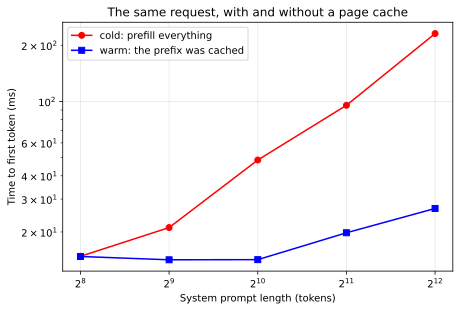

In [4]:
plt.figure(figsize=(7,4.5))
plt.plot(prefixes, cold, 'ro-', label='cold: prefill everything')
plt.plot(prefixes, warm, 'bs-', label='warm: the prefix was cached')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('System prompt length (tokens)')
plt.ylabel('Time to first token (ms)')
plt.title('The same request, with and without a page cache')
plt.legend()
plt.grid(alpha=.3)
plt.show()

### Why this feels like cheating

The warm line is nearly flat. It has to be: the work left is prefilling 32
tokens, and that does not depend on how long the prompt you skipped was.

So the longer your system prompt, the more prefix caching is worth, which is
the opposite of how costs usually behave. Teams discover that they can afford
a much longer system prompt than they thought, because the second user
onwards does not pay for it.

# What it costs to keep

A hit needs the blocks still resident. They compete with running sequences
for the same pool, so the cache needs an eviction policy, and the natural one
is least-recently-used.

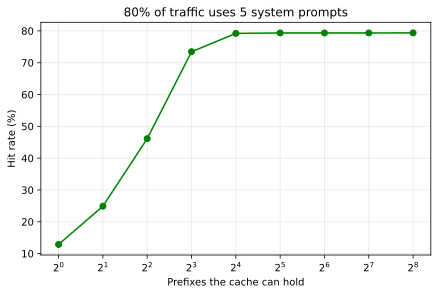

room for    1 prefixes:  12.9% of requests hit
room for    8 prefixes:  73.5% of requests hit
room for  128 prefixes:  79.3% of requests hit


In [5]:
# a workload: a few popular system prompts, a long tail of unique ones
rng = np.random.default_rng(0)
popular = rng.integers(0, 5, size=4000)
unique = rng.integers(100, 100000, size=4000)
mix = np.where(rng.random(4000) < 0.8, popular, unique)

def hit_rate(capacity, stream):
  from collections import OrderedDict
  cache = OrderedDict()
  hits = 0
  for key in stream:
    if key in cache:
      hits += 1
      cache.move_to_end(key)
    else:
      cache[key] = 1
      if len(cache) > capacity: cache.popitem(last=False)
  return hits/len(stream)

capacities = [1,2,4,8,16,32,64,128,256]
rates = [hit_rate(cold_ms, mix) for cold_ms in capacities]

plt.figure(figsize=(7,4.2))
plt.plot(capacities, [100*rate for rate in rates], 'go-')
plt.xscale('log', base=2)
plt.xlabel('Prefixes the cache can hold')
plt.ylabel('Hit rate (%)')
plt.title('80% of traffic uses 5 system prompts')
plt.grid(alpha=.3)
plt.show()

for cold_ms in (1, 8, 128):
  print(f'room for {cold_ms:>4} prefixes: {100*hit_rate(cold_ms, mix):5.1f}% of requests hit')

The curve saturates almost immediately, because the distribution is what it
is: a handful of prompts account for most traffic. You do not need a big
cache. You need a correct one.

    ./vc guide 9